In [1]:
from pylab import *
import torch
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)

from synchrotron_simulator_gpu_Dataset_4D import SimulationRunner
from automate_dataset_collection import DataAutomation, SimulationDataset
from net import build_model, build_model_from_train_dir, train_model
from data import gen_data, load_data_from_dir, prepare_data_for_training
from utils import convert_defaultdict_to_dict, deserialize_minmax_scaler

--->Creating save directory: exps/test/run_2025-10-21_18-14-09/figs
--->Creating save directory: exps/test/run_2025-10-21_18-14-09/training
--->Creating save directory: exps/test/run_2025-10-21_18-14-09/benchmarks


In [2]:
# model_train_dir = "../exps/test/run_2025-10-11_12-41-56/training/train_2025-10-11_12-42-01"
model_train_dir = "../exps/exp_LSTM_2000_mix/GOLDEN_run_2025-01-17_00-19-35/training/train_2025-01-17_03-16-42"
device = 'cuda:0'
model, data_sub_cfg = build_model_from_train_dir(model_train_dir, device)

model = model.eval()

nb_all_model_params =  564230
nb_trainable_parameters =  564230
model number_of_parameters:  (564230, 564230)
Checkpoint Loaded.


In [3]:
model

QuadErrorCorrectionLSTM(
  (lstm): LSTM(16, 256, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=6, bias=True)
)

In [4]:
merged_config_path = "../data/Sim2000_6000turns_10parts_FODOErr-123457-136-_avgTrue_tgtquad_misalign_deltas_1/merged_config-final.pt"

merged_config = torch.load(merged_config_path)

/tmp/ipykernel_1166086/1409391608.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  merged_config = torch.load(merged_config_path)


In [5]:
merged_config

{'p': 5.344286e-19,
 'G': 1.0,
 'q': 1.602e-19,
 'n_turns': 6000,
 'num_particles': 10,
 'window_size': 10,
 'use_thin_lens': True,
 'x0_mean_std': (0.0, 0.05),
 'xp0_mean_std': (0.0, 0.0),
 'y0_mean_std': (0.0, 0.05),
 'yp0_mean_std': (0.0, 0.0),
 'particles_sampling_method': 'from_twiss_params',
 'sampling_circle_radius': 0.01,
 'mag_field_range': [0.1, 2.0],
 'dipole_length_range': [0.2, 14.0],
 'horizontal_tune_range': [0.1, 0.8],
 'vertical_tune_range': [0.1, 0.8],
 'total_dipole_bending_angle_range': (4.71238898038469, 6.283185307179586),
 'use_gpu': True,
 'verbose': True,
 'figs_save_dir': 'exps/exp_LSTM_1000_mix/run_2025-01-17_00-19-35/figs',
 'target_data': 'quad_misalign_deltas',
 'reject_multiple_error_types': False,
 'start_rev': 5500,
 'end_rev': 6000,
 'apply_avg': True,
 'fodo_cell_indices': [0, 1, 2, 3, 4, 5, 6, 7],
 'planes': ['x', 'y'],
 'random_criterion': 'normal',
 'delta_range': (0, 5e-05),
 'quad_tilt_angle_range': (0, 0.01),
 'dipole_tilt_angle_range': (0, 0.05

In [6]:
# merged_config

In [7]:
data_sub_cfg['merged_config'] = merged_config

In [8]:
DATA_DIR = "../data/Sim2000_6000turns_10parts_FODOErr-123457-136-_avgTrue_tgtquad_misalign_deltas_1"
sim_data = load_data_from_dir(DATA_DIR)

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/data.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sim_data[C.DATA_KEY_DATA_AUTOMATION] =                t

All Input Tensors Shape: torch.Size([2000, 101, 8, 2])
All Target Tensors Shape: torch.Size([2000, 6])


/home/aribra/jnps/thesis/public_repo/lattice_correction_net/data.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sim_data[C.DATA_KEY_DATASET_SCALERS] =                t

In [9]:
dataset_scalers = {
    'input_scaler': deserialize_minmax_scaler(data_sub_cfg['input_scaler_config']),
    'target_scaler': deserialize_minmax_scaler(data_sub_cfg['target_scaler_config'])
}

In [10]:
data_sub_cfg['input_scaler_config']

{'min_': [0.0037229350793177574, 0.004963501015271543],
 'scale_': [84146.04152744994, 6667.041810538634],
 'data_min_': [-1.192834406538168e-05, -0.0001507360429968685],
 'data_max_': [1.1839856597362086e-05, 0.00014924707647878677],
 'data_range_': [2.3768200662743766e-05, 0.00029998311947565526],
 'feature_range': [-1, 1]}

In [11]:
data_sub_cfg['target_scaler_config']

{'min_': [0.028895915803687888,
  -0.03221250770295114,
  -0.06434873935126084,
  -0.019636958344722677,
  -0.053231950775075365,
  0.005792023407808822],
 'scale_': [5828.826679808204,
  6303.575686138247,
  6180.245066389801,
  6122.637281585369,
  6558.0818128844385,
  5934.114825823509],
 'data_min_': [-0.00017651852976996452,
  -0.00015352992340922356,
  -0.00015139387687668204,
  -0.00016012103878892958,
  -0.0001443666114937514,
  -0.00016949318523984402],
 'data_max_': [0.0001666036987444386,
  0.00016375031555071473,
  0.00017221788584720343,
  0.0001665355812292546,
  0.00016060061170719564,
  0.00016754107491578907],
 'data_range_': [0.0003431222285144031,
  0.0003172802389599383,
  0.0003236117627238855,
  0.0003266566200181842,
  0.00030496722320094705,
  0.0003370342601556331],
 'feature_range': [-1, 1]}

In [12]:
sim_data.keys()

dict_keys(['all_error_values_dipole_tilt', 'all_error_values_quad_misalign', 'all_error_values_quad_tilt', 'data_automation', 'dataset_scalers', 'input_tensors', 'input_tensors_scaled', 'merged_config', 'target_tensors', 'target_tensors_scaled', 'base_configuration'])

In [13]:
sim_data['input_tensors_scaled'].shape

torch.Size([2000, 101, 8, 2])

In [14]:
sim_data['input_tensors_scaled'][0].shape

torch.Size([101, 8, 2])

In [98]:
inpt = torch.tensor(sim_data['input_tensors_scaled'][0][None, ...], dtype=torch.float32).to(device)
n_samples, n_turns, n_BPMs, n_planes = inpt.shape
input_size = n_BPMs * n_planes
inpt_reshaped = inpt.reshape(n_samples, n_turns, input_size)

/tmp/ipykernel_2106141/2589006276.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inpt = torch.tensor(sim_data['input_tensors_scaled'][0][None, ...], dtype=torch.float32).to(device)


In [99]:
inpt_reshaped.shape

torch.Size([1, 101, 16])

In [100]:
output = model(inpt_reshaped)

In [101]:
output = output.detach().cpu().numpy()

In [15]:
output

array([[-0.27610922,  0.06295346,  0.83552104, -0.33085057, -0.23911105,
        -0.19915645]], dtype=float32)

In [102]:
output

array([[-0.27625024,  0.06284443,  0.8351032 , -0.33091292, -0.23909453,
        -0.19902603]], dtype=float32)

In [26]:
output_inverse_transformed = dataset_scalers['target_scaler'].inverse_transform(output)

In [27]:
output_inverse_transformed


array([[-5.2327021e-05,  1.5097142e-05,  1.4560422e-04, -5.0829993e-05,
        -2.8343517e-05, -3.4537326e-05]], dtype=float32)

In [ ]:
dataset_scalers['target_scaler'].inverse_transform(predicted_errors_scaled_values)

In [37]:
sim_data['target_tensors_scaled'][0][None, ...]

tensor([[-0.2759,  0.0630,  0.8355, -0.3309, -0.2390, -0.1990]])

In [38]:
sim_data['target_tensors'][0][None, ...]

tensor([[-5.2294e-05,  1.5107e-05,  1.4559e-04, -5.0831e-05, -2.8323e-05,
         -3.4516e-05]])

In [24]:
input_tensor_eval = torch.load("input_tensor_eval.pt")

/tmp/ipykernel_1176102/2809237756.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  input_tensor_eval = torch.load("input_tensor_eval.pt")


In [25]:
input_tensor_eval.shape

torch.Size([1, 101, 8, 2])

In [7]:
plot(input_tensor_eval[0, :, 2, 1])

NameError: name 'input_tensor_eval' is not defined

In [27]:
input_tensor_eval

tensor([[[[ 4.3973e-06, -2.3738e-04],
          [ 6.9426e-06, -9.5272e-05],
          [ 6.1802e-06,  8.9916e-05],
          ...,
          [-2.4269e-06,  1.5064e-04],
          [-1.2925e-06, -1.2767e-05],
          [ 1.7540e-06, -1.8991e-04]],

         [[ 2.7166e-06, -2.3927e-04],
          [ 5.3979e-06, -9.3726e-05],
          [ 6.6122e-06,  9.3687e-05],
          ...,
          [-3.3728e-06,  1.4746e-04],
          [-3.3819e-06, -1.6441e-05],
          [ 9.8479e-07, -1.9114e-04]],

         [[ 4.1815e-06, -2.3708e-04],
          [ 7.2673e-06, -8.9879e-05],
          [ 6.5761e-06,  9.6097e-05],
          ...,
          [-2.6852e-06,  1.4412e-04],
          [-1.3710e-06, -1.6866e-05],
          [ 1.9196e-06, -1.8831e-04]],

         ...,

         [[ 3.5566e-06, -2.3239e-04],
          [ 7.1736e-06, -8.8521e-05],
          [ 7.0362e-06,  9.3044e-05],
          ...,
          [-3.2791e-06,  1.4557e-04],
          [-1.5210e-06, -1.2153e-05],
          [ 2.4085e-06, -1.8410e-04]],

     

In [28]:
inpt = torch.tensor(input_tensor_eval, dtype=torch.float32).to(device)
n_samples, n_turns, n_BPMs, n_planes = inpt.shape
input_size = n_BPMs * n_planes
inpt_reshaped = inpt.reshape(n_samples, n_turns, input_size)

/tmp/ipykernel_1176102/468325602.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inpt = torch.tensor(input_tensor_eval, dtype=torch.float32).to(device)


In [29]:
input_data_flat = inpt_reshaped.cpu().numpy().reshape(-1, n_planes)

# inpt_transformed = dataset_scalers['input_scaler'].transform(input_data_flat)
inpt_transformed = input_data_flat

input_data_scaled = inpt_transformed.reshape(n_samples, n_turns, n_BPMs, n_planes)

input_data_scaled = input_data_scaled.reshape(n_samples, n_turns, input_size)

input_tensor_model = torch.tensor(input_data_scaled, dtype=torch.float32).to(device)

In [30]:
input_tensor_model.shape

torch.Size([1, 101, 16])

In [31]:
output_2 = model(input_tensor_model)
output_2 = output_2.detach().cpu().numpy()
output_inverse_transformed = dataset_scalers['target_scaler'].inverse_transform(output_2)

In [32]:
output_2

array([[ 0.02182887, -0.03227738, -0.07225168, -0.01990944, -0.06171446,
        -0.0018324 ]], dtype=float32)

In [33]:
output_inverse_transformed

array([[-1.2124301e-06, -1.0290629e-08, -1.2787431e-06, -4.4503601e-08,
        -1.2934429e-06, -1.2848466e-06]], dtype=float32)

In [44]:
inpt_reshaped

tensor([[[ 1.0935e-06,  3.7081e-05,  1.2904e-07,  ...,  1.5945e-04,
          -5.7028e-07,  1.2254e-04],
         [-1.1404e-06,  3.2603e-05, -3.5564e-07,  ...,  1.5516e-04,
           3.5848e-07,  1.1843e-04],
         [ 1.1407e-06,  3.1957e-05,  5.6768e-07,  ...,  1.5160e-04,
          -1.3201e-07,  1.1873e-04],
         ...,
         [ 8.7555e-07,  3.7839e-05,  1.0318e-06,  ...,  1.5459e-04,
           5.3584e-07,  1.2493e-04],
         [-7.0871e-07,  4.0333e-05, -1.1113e-06,  ...,  1.5909e-04,
          -7.2883e-07,  1.2657e-04],
         [ 5.1287e-07,  3.7805e-05,  1.1452e-06,  ...,  1.5981e-04,
           8.9201e-07,  1.2330e-04]]], device='cuda:0')

In [5]:
data_automation_pt = "/home/aribra/jnps/thesis/public_repo/lattice_correction_net/data/Sim2000_6000turns_20parts_FODOErr-123457-136-_avgTrue_tgtquad_misalign_deltas_1/data_automation-final.pt"
data_automation = torch.load(data_automation_pt)

/tmp/ipykernel_78874/1413411801.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_automation = torch.load(data_automation_pt)


In [8]:
type(data_automation)

automate_dataset_collection.DataAutomation

In [10]:
data_automation.

2000

Text(0.5, 1.0, 'Sim 500 - BPM 5 - Y values')

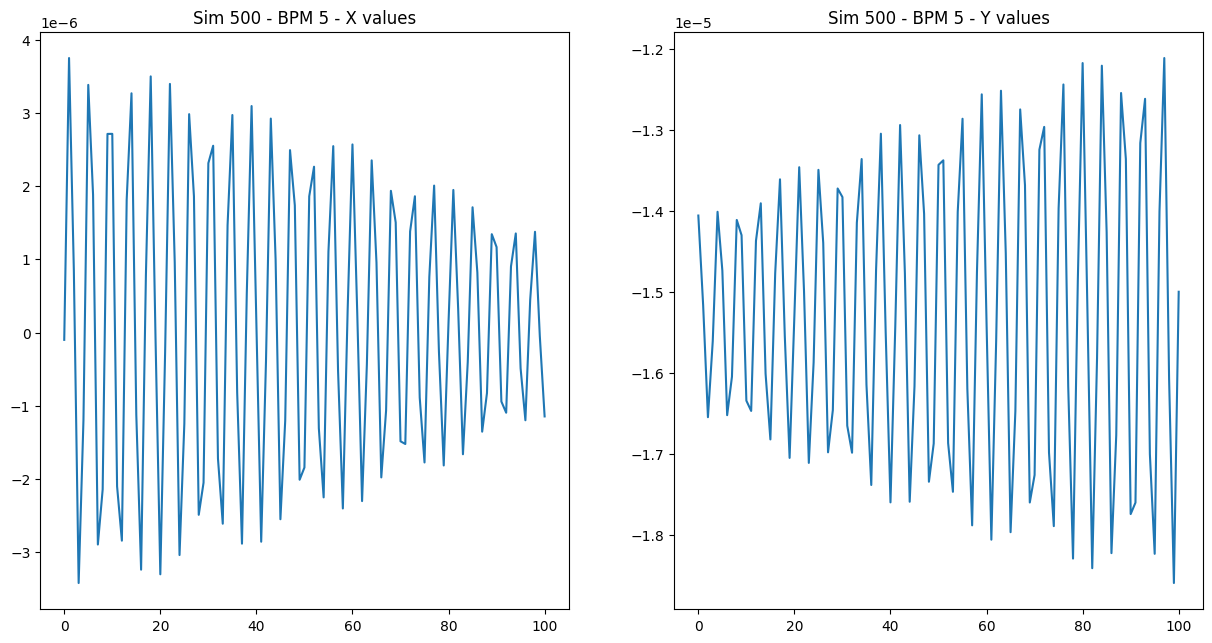

In [55]:
BPM_ix = 5
SIM_ix = 500

xs = sim_data['input_tensors'][SIM_ix, :, BPM_ix, 0]
ys = sim_data['input_tensors'][SIM_ix, :, BPM_ix, 1]

figure(figsize=(15,7.5))
subplot(1, 2, 1)
plot(xs)
title(f"Sim {SIM_ix} - BPM {BPM_ix} - X values")

subplot(1, 2, 2)
plot(ys)
title(f"Sim {SIM_ix} - BPM {BPM_ix} - Y values")

In [280]:
xx = torch.load("/home/aribra/jnps/thesis/public_repo/lattice_correction_net/data/Sim1000_2000turns_10parts_FODOErr-123457--_avgTrue_tgtquad_misalign_deltas_1/input_tensors-final.pt")



/tmp/ipykernel_1166086/640317409.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  xx = torch.load("/home/aribra/jnps/thesis/public_repo/lattice_correction_net/data/Sim100

In [281]:
xx.shape

torch.Size([1000, 101, 8, 2])

In [282]:
# sim_data['input_tensors']

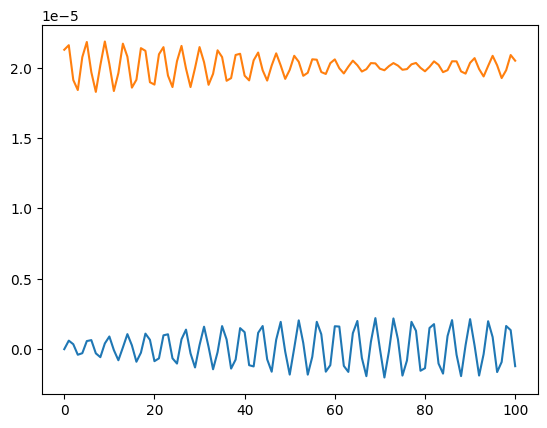

In [283]:
plot(sim_data['input_tensors'][0, :, 0, 0])
plot(sim_data['input_tensors'][0, :, 0, 1])

Betatron tune (Y): 0.125


Text(0.5, 1.0, 'sim_idx=953; Qy=0.125')

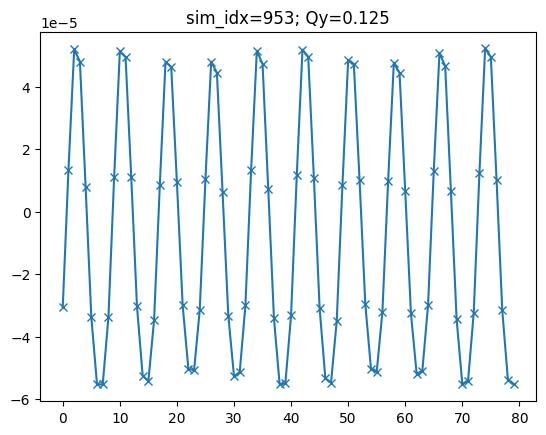

In [348]:
# xs_all_bpms = sim_data['input_tensors'][0, :10, :, 0].ravel()
sim_idx = np.random.randint(2000)
# sim_idx = 1795
ys_all_bpms = sim_data['input_tensors'][sim_idx, :10, :, 1]
ys_all_bpms_ravel = ys_all_bpms.flatten()

# plot(xs_all_bpms)
plot(ys_all_bpms_ravel, 'x-')


y_signal = ys_all_bpms.numpy().ravel()
N = len(y_signal)
fft_vals = np.fft.fft(y_signal)  # remove DC component
freqs = np.fft.fftfreq(N, d=1)  # assuming 1 turn per sample
power = np.abs(fft_vals)**2
half = N // 2
freqs = freqs[:half]
power = power[:half]
tune_index = np.argmax(power)
tune = freqs[tune_index]
print("Betatron tune (Y):", tune)
title(f"sim_idx={sim_idx}; Qy={tune}")
# print(y_signal)
# ys_all_bpms

In [276]:
1 / tune

10.0

Betatron tune (Y): 0.125
